# Production email classifier training

Train, persist, reload, and evaluate the Sentence Transformer + Random Forest classifier used by the backend.

In [1]:
import json
from pathlib import Path
import numpy as np
import joblib
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from server.classification.preprocessing import preprocess_email
from server.classification.embeddings import SentenceEmbeddingService

RANDOM_STATE = 42
DATA_DIR = Path('data_v2')
MODEL_PATH = Path('models/random_forest_classifier.joblib')
EMBEDDING_NAME = 'models/all-MiniLM-L6-v2'

## Load data and use production preprocessing

In [2]:
truth = json.loads((DATA_DIR / 'ground_truth.json').read_text(encoding='utf-8'))
rows = []
for path in sorted((DATA_DIR / 'inbox').glob('*.json')):
    email = json.loads(path.read_text(encoding='utf-8'))
    rows.append({**email, 'label': truth[email['email_id']]['category']})

groups = {}
for row in rows:
    groups.setdefault(row['label'], []).append(row)
labels = sorted(groups)
n_train_per_label = int(np.floor(min(len(items) for items in groups.values()) * 0.40))
rng = np.random.default_rng(RANDOM_STATE)
train_rows, test_rows = [], []
for label in labels:
    indices = rng.permutation(len(groups[label]))
    train_indices = indices[:n_train_per_label]
    test_indices = indices[n_train_per_label:]
    train_rows.extend(groups[label][i] for i in train_indices)
    test_rows.extend(groups[label][i] for i in test_indices)

assert len(train_rows) == n_train_per_label * len(labels)
assert {row['email_id'] for row in train_rows}.isdisjoint({row['email_id'] for row in test_rows})
print(f'Train: {len(train_rows)} ({n_train_per_label} per label); test: {len(test_rows)}')
print({label: sum(row['label'] == label for row in train_rows) for label in labels})

Train: 80 (16 per label); test: 440
{'BL_COMPARISON': 16, 'GENERAL': 16, 'INVOICE_QUERY': 16, 'SI_REQUEST': 16, 'SPAM': 16}


## Generate embeddings and train the production Random Forest

In [3]:
embedding_service = SentenceEmbeddingService(EMBEDDING_NAME)
X_train = embedding_service.encode([preprocess_email(row) for row in train_rows])
X_test = embedding_service.encode([preprocess_email(row) for row in test_rows])
y_train = [row['label'] for row in train_rows]
y_test = [row['label'] for row in test_rows]

classifier = RandomForestClassifier(n_estimators=500, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
classifier.fit(X_train, y_train)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(classifier, MODEL_PATH)
print(f'Saved trained model to {MODEL_PATH.resolve()}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Saved trained model to C:\Users\shamg\OneDrive\Documents\dareDEVils_averis\dareDEVils-AverisXMonash-Hackathon\models\random_forest_classifier.joblib


## Reload the saved artifact and evaluate production accuracy

The accuracy below is calculated using the model reloaded from disk, matching the backend loading path.

Final reloaded-model test accuracy: 100.00% (440/440)
               precision    recall  f1-score   support

BL_COMPARISON      1.000     1.000     1.000       204
      GENERAL      1.000     1.000     1.000        44
INVOICE_QUERY      1.000     1.000     1.000        59
   SI_REQUEST      1.000     1.000     1.000       109
         SPAM      1.000     1.000     1.000        24

     accuracy                          1.000       440
    macro avg      1.000     1.000     1.000       440
 weighted avg      1.000     1.000     1.000       440



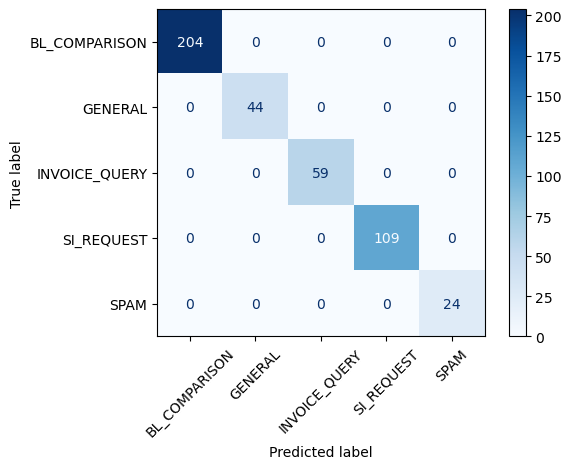

In [4]:
reloaded_classifier = joblib.load(MODEL_PATH)
reloaded_predictions = reloaded_classifier.predict(X_test)
accuracy = accuracy_score(y_test, reloaded_predictions)
print(f'Final reloaded-model test accuracy: {accuracy:.2%} ({(reloaded_predictions == np.asarray(y_test)).sum()}/{len(y_test)})')
print(classification_report(y_test, reloaded_predictions, digits=3, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, reloaded_predictions, xticks_rotation=45, cmap='Blues')
plt.tight_layout(); plt.show()

## Production inference check

In [16]:
def predict_with_saved_model(email):
    text = preprocess_email(email)
    vector = embedding_service.encode([text])
    probabilities = reloaded_classifier.predict_proba(vector)[0]
    index = int(probabilities.argmax())
    return {'category': str(reloaded_classifier.classes_[index]), 'confidence': float(probabilities[index])}

print(predict_with_saved_model(test_rows[20]))

{'category': 'BL_COMPARISON', 'confidence': 0.786}
